In [1]:
# ============================================================
# Collapse Timescale Experiment
# Primary outcome: TIME-TO-COLLAPSE (epoch), not binary rate
#
# MOTIVATION:
#   Quick Kill showed collapse is near-universal in realistic
#   regimes. The informative quantity is HOW FAST collapse
#   occurs, not WHETHER it occurs. Clinically: "will it collapse
#   within my training budget T?"
#
# KEY FINDING FROM QUICK KILL:
#   - Theory A (ratio only) DEAD: collapse epoch varies at fixed ratio
#   - Theory B (Ito noise) DEAD (wrong sign): larger N → faster collapse
#   - Noise is PROTECTIVE: small groups collapse less (noisy estimates)
#   - Drift drives collapse: more data → sharper loss estimates → faster
#
# THIS NOTEBOOK:
#   Fit epoch ~ N_min^a · ratio^b · p^c
#   Three 1D sweeps (vary one, fix others) + power-law regression
#   Gives the exponents directly → correct functional form for MAD†
#
# EXPERIMENTAL DESIGN:
#   Sweep 1: vary N_min (10→2000), fix ratio=10, p=0.10
#   Sweep 2: vary ratio (2→50),   fix N_min=200, p=0.10
#   Sweep 3: vary p (0.02→0.50),  fix N_min=200, ratio=10
#   5 seeds each, record mean collapse epoch
#   Fit log(epoch) = a·log(N_min) + b·log(ratio) + c·log(p) + const
#
# OUTPUT:
#   timescale_results.csv
#   timescale_figure.png
#   timescale_summary.json  <- includes fitted exponents a, b, c
#
# RUNTIME: ~45 min CPU. No GPU needed (but GPU faster).
# ============================================================

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import json, math, warnings
warnings.filterwarnings('ignore')

SEEDS        = [42, 0, 1, 7, 99]
N_EPOCHS     = 50       # long enough to capture slow collapses
DRO_ETA      = 0.1
ADAMW_LR     = 1e-3
ADAMW_WD     = 1e-4
BATCH_SIZE   = 64
COLLAPSE_THR = 0.01
DIM          = 64
SEPARABILITY = 2.0
SIGMA_MAJ    = 1.0
SIGMA_MIN    = 1.0
N_TEST       = 500

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Epochs per run: {N_EPOCHS}')
print(f'Seeds: {SEEDS}')
print(f'Fitting: log(epoch) = a·log(N_min) + b·log(ratio) + c·log(p) + const')

Device: cuda
Epochs per run: 50
Seeds: [42, 0, 1, 7, 99]
Fitting: log(epoch) = a·log(N_min) + b·log(ratio) + c·log(p) + const


In [2]:
# ── CELL 2: Data generator ────────────────────────────────────
def generate_groups(N_maj, N_min, p_min, p_maj=0.5,
                    sigma_maj=SIGMA_MAJ, sigma_min=SIGMA_MIN,
                    sep=SEPARABILITY, dim=DIM, seed=42):
    rng = np.random.RandomState(seed)

    def make_group(n, sigma, group_id, offset, p_class):
        n_pos = max(1, int(n * p_class))
        n_neg = n - n_pos
        c_pos = np.zeros(dim); c_pos[0] = +sep/2; c_pos[1] = offset
        c_neg = np.zeros(dim); c_neg[0] = -sep/2; c_neg[1] = offset
        X = np.vstack([
            rng.randn(n_pos, dim) * sigma + c_pos,
            rng.randn(n_neg, dim) * sigma + c_neg,
        ]).astype(np.float32)
        y = np.array([1]*n_pos + [0]*n_neg, dtype=np.int64)
        g = np.array([group_id*2 + yi for yi in y], dtype=np.int64)
        return X, y, g

    XA, yA, gA = make_group(N_maj, sigma_maj, 0, +1.0, p_maj)
    XB, yB, gB = make_group(N_min, sigma_min, 1, -1.0, p_min)
    X_tr = np.vstack([XA, XB])
    y_tr = np.concatenate([yA, yB])
    g_tr = np.concatenate([gA, gB])

    XAt, yAt, gAt = make_group(N_TEST, sigma_maj, 0, +1.0, p_maj)
    XBt, yBt, gBt = make_group(N_TEST, sigma_min, 1, -1.0, p_min)
    X_te = np.vstack([XAt, XBt])
    y_te = np.concatenate([yAt, yBt])
    g_te = np.concatenate([gAt, gBt])

    return (X_tr, y_tr, g_tr), (X_te, y_te, g_te)


print('Data generator defined.')
print(f'Sanity check:')
(Xt,yt,gt),(Xe,ye,ge) = generate_groups(1000,100,p_min=0.1)
print(f'  Train: {Xt.shape}  groups: {dict(zip(*np.unique(gt,return_counts=True)))}')

Data generator defined.
Sanity check:
  Train: (1100, 64)  groups: {np.int64(0): np.int64(500), np.int64(1): np.int64(500), np.int64(2): np.int64(90), np.int64(3): np.int64(10)}


In [3]:
# ── CELL 3: DRO runner — returns epoch AND gradient steps ────
class LinearClassifier(nn.Module):
    def __init__(self): super().__init__(); self.fc = nn.Linear(DIM, 2)
    def forward(self, x): return self.fc(x)

def run_dro_timescale(X_tr, y_tr, g_tr, X_te, y_te, g_te,
                      eta=DRO_ETA, seed=42):
    """
    Returns collapse_epoch, collapse_step, and final min_q.
    collapse_step is the global gradient-step count at first collapse,
    which is the natural time unit — steps_per_epoch = ceil(N/batch_size).
    If no collapse within N_EPOCHS, returns censored values.
    """
    torch.manual_seed(seed); np.random.seed(seed)

    tr_ds = TensorDataset(torch.from_numpy(X_tr).float(),
                          torch.from_numpy(y_tr).long(),
                          torch.from_numpy(g_tr).long())
    te_ds = TensorDataset(torch.from_numpy(X_te).float(),
                          torch.from_numpy(y_te).long(),
                          torch.from_numpy(g_te).long())
    tr_ld = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)
    te_ld = DataLoader(te_ds, batch_size=512, shuffle=False)

    model    = LinearClassifier().to(device)
    opt      = optim.AdamW(model.parameters(), lr=ADAMW_LR, weight_decay=ADAMW_WD)
    n_groups = int(g_tr.max()) + 1
    q        = torch.ones(n_groups).to(device) / n_groups

    collapse_epoch = None
    collapse_step  = None
    global_step    = 0  # counts every gradient update

    steps_per_epoch = math.ceil(len(X_tr) / BATCH_SIZE)

    for epoch in range(1, N_EPOCHS + 1):
        model.train()
        for xb, yb, gb in tr_ld:
            xb, yb, gb = xb.to(device), yb.to(device), gb.to(device)
            opt.zero_grad()
            losses = nn.CrossEntropyLoss(reduction='none')(model(xb), yb)
            g_loss = torch.zeros(n_groups).to(device)
            for g in range(n_groups):
                mask = gb == g
                if mask.sum() > 0:
                    g_loss[g] = losses[mask].mean()
            q = q * torch.exp(eta * g_loss.detach())
            q = q / q.sum()
            (q * g_loss).sum().backward()
            opt.step()
            global_step += 1

            # Check collapse at step level (not just epoch end)
            if collapse_step is None and float(q.min().item()) < COLLAPSE_THR:
                collapse_step  = global_step
                collapse_epoch = epoch

    final_min_q  = float(q.min().item())
    max_steps    = global_step  # total steps in run

    return {
        'collapse_epoch': collapse_epoch if collapse_epoch else N_EPOCHS + 1,
        'collapse_step':  collapse_step  if collapse_step  else max_steps + 1,
        'steps_per_epoch': steps_per_epoch,
        'total_steps':    max_steps,
        'final_min_q':    final_min_q,
        'collapsed':      collapse_epoch is not None,
    }

print('DRO runner defined (tracks epoch AND gradient steps).')
print(f'Batch size: {BATCH_SIZE}')
print(f'Example: N_min=100 → train_size≈1100 → steps_per_epoch≈{math.ceil(1100/BATCH_SIZE)}')
print(f'Example: N_min=1000 → train_size≈11000 → steps_per_epoch≈{math.ceil(11000/BATCH_SIZE)}')
print(f'If collapse_step is ~constant across N, the epoch law is pure unit conversion.')

DRO runner defined (tracks epoch AND gradient steps).
Batch size: 64
Example: N_min=100 → train_size≈1100 → steps_per_epoch≈18
Example: N_min=1000 → train_size≈11000 → steps_per_epoch≈172
If collapse_step is ~constant across N, the epoch law is pure unit conversion.


In [4]:
# ── CELL 4: SWEEP 1 — Vary N_min, fix ratio=10, p=0.10 ────────
# PRIMARY TEST: record collapse in BOTH epochs and steps.
# Prediction (epoch-clock hypothesis):
#   collapse_epoch ~ N_min^{-0.70}  (as before)
#   collapse_step  ~ N_min^{0}      (flat — steps cancel epochs)
# If collapse_step is ALSO decreasing: N is real in step-space too.
# If collapse_step is FLAT: the scaling law is unit conversion.

print('='*62)
print('SWEEP 1: N_min varies (ratio=10, p=0.10)')
print('Epoch hypothesis: collapse_epoch ~ N_min^a (a<0, larger→faster)')
print('Step  hypothesis: collapse_step  ~ N_min^0 (FLAT if unit conversion)')
print('='*62)

RATIO_S1  = 10
P_S1      = 0.10
NMIN_VALS = [10, 25, 50, 100, 200, 400, 800, 1500, 2000]

records_S1 = []
for N_min in NMIN_VALS:
    N_maj = N_min * RATIO_S1
    epoch_list, step_list, spe_list = [], [], []

    for seed in SEEDS:
        (Xtr,ytr,gtr),(Xte,yte,gte) = generate_groups(
            N_maj, N_min, p_min=P_S1, seed=seed)
        res = run_dro_timescale(Xtr, ytr, gtr, Xte, yte, gte, seed=seed)
        epoch_list.append(res['collapse_epoch'])
        step_list.append(res['collapse_step'])
        spe_list.append(res['steps_per_epoch'])

    mean_ep  = float(np.mean(epoch_list))
    mean_st  = float(np.mean(step_list))
    mean_spe = float(np.mean(spe_list))
    std_ep   = float(np.std(epoch_list))
    std_st   = float(np.std(step_list))
    col_rate = sum(e <= N_EPOCHS for e in epoch_list) / len(SEEDS)
    censored = sum(e > N_EPOCHS for e in epoch_list)

    # Theoretical prediction: if unit-conversion, steps ≈ epoch * spe
    # spe ∝ N (more data = more batches per epoch)
    # if epoch ~ N^{-0.70} and spe ~ N^1 then steps ~ N^{0.30}
    # (not flat — still increasing but sublinearly)
    # True unit conversion (flat steps) requires epoch ~ N^{-1} exactly

    records_S1.append({
        'N_min':         N_min,
        'N_maj':         N_maj,
        'ratio':         RATIO_S1,
        'p_min':         P_S1,
        'mean_epoch':    round(mean_ep, 2),
        'std_epoch':     round(std_ep, 2),
        'mean_step':     round(mean_st, 1),
        'std_step':      round(std_st, 1),
        'mean_spe':      round(mean_spe, 1),
        'collapse_rate': round(col_rate, 3),
        'censored':      censored,
        'log_N_min':     round(math.log(N_min), 4),
        'log_epoch':     round(math.log(mean_ep), 4) if mean_ep > 0 else None,
        'log_step':      round(math.log(mean_st), 4) if mean_st > 0 else None,
    })
    print(f'  N_min={N_min:>5}  spe={mean_spe:>5.0f}  '
          f'epoch={mean_ep:>6.1f}±{std_ep:.1f}  '
          f'step={mean_st:>7.0f}±{std_st:.0f}  '
          f'collapse={col_rate:.0%}  cens={censored}/5')

df_S1 = pd.DataFrame(records_S1)

# Power-law fits
fit_rows = df_S1[(df_S1['censored'] == 0) & df_S1['log_epoch'].notna()]
print()
if len(fit_rows) >= 3:
    sl_ep, ic_ep, r_ep, _, _ = stats.linregress(
        fit_rows['log_N_min'], fit_rows['log_epoch'])
    sl_st, ic_st, r_st, _, _ = stats.linregress(
        fit_rows['log_N_min'], fit_rows['log_step'])
    print(f'Epoch fit: epoch ~ N_min^{sl_ep:.3f}  (R²={r_ep**2:.3f})')
    print(f'Step  fit: step  ~ N_min^{sl_st:.3f}  (R²={r_st**2:.3f})')
    print()
    print('VERDICT:')
    if abs(sl_st) < 0.15:
        print(f'  Step exponent ≈ 0: UNIT CONVERSION CONFIRMED.')
        print(f'  The epoch law (N^{sl_ep:.2f}) is entirely explained by')
        print(f'  steps-per-epoch ∝ N. The true scaling law in step-space is flat.')
        print(f'  Real MAD‡ score needs NO N_min term (or N^0 = 1).')
    elif sl_st < -0.15:
        print(f'  Step exponent = {sl_st:.3f} < 0: N IS REAL IN STEP-SPACE.')
        print(f'  Larger N causes faster collapse even controlling for steps/epoch.')
        print(f'  The N exponent in MAD‡ is a genuine physical effect, not unit conversion.')
        print(f'  True step exponent: {sl_st:.3f}  (compare epoch: {sl_ep:.3f})')
        print(f'  Partial unit conversion: epoch exponent absorbed ~{sl_ep-sl_st:.3f} from spe.')
    else:
        print(f'  Step exponent = {sl_st:.3f} > 0: UNEXPECTED.')
        print(f'  Larger N → MORE steps to collapse. Noise protection wins in step-space.')

SWEEP 1: N_min varies (ratio=10, p=0.10)
Epoch hypothesis: collapse_epoch ~ N_min^a (a<0, larger→faster)
Step  hypothesis: collapse_step  ~ N_min^0 (FLAT if unit conversion)
  N_min=   10  spe=    2  epoch=  37.2±6.4  step=     74±13  collapse=100%  cens=0/5
  N_min=   25  spe=    5  epoch=  15.0±1.4  step=     75±7  collapse=100%  cens=0/5
  N_min=   50  spe=    9  epoch=  10.4±1.4  step=     87±10  collapse=100%  cens=0/5
  N_min=  100  spe=   18  epoch=   5.0±0.6  step=     86±15  collapse=100%  cens=0/5
  N_min=  200  spe=   35  epoch=   3.4±0.5  step=     99±18  collapse=100%  cens=0/5
  N_min=  400  spe=   69  epoch=   2.0±0.0  step=     92±13  collapse=100%  cens=0/5
  N_min=  800  spe=  138  epoch=   1.0±0.0  step=     91±10  collapse=100%  cens=0/5
  N_min= 1500  spe=  258  epoch=   1.0±0.0  step=     94±20  collapse=100%  cens=0/5
  N_min= 2000  spe=  344  epoch=   1.0±0.0  step=     97±7  collapse=100%  cens=0/5

Epoch fit: epoch ~ N_min^-0.705  (R²=0.977)
Step  fit: step  ~

In [6]:
# ── CELL 5: SWEEP 2 — Vary ratio, fix N_min=200, p=0.10 ───────
print('='*55)
print('SWEEP 2: ratio varies (N_min=200, p=0.10 fixed)')
print('Expects: epoch ~ ratio^b  (b < 0: higher ratio → faster collapse)')
print('Also tracking steps to check unit-conversion hypothesis')
print('='*55)

NMIN_S2    = 200
P_S2       = 0.10
RATIO_VALS = [2, 3, 5, 8, 10, 15, 20, 30, 50]

records_S2 = []
for ratio in RATIO_VALS:
    N_maj = NMIN_S2 * ratio
    epoch_list, step_list = [], []

    for seed in SEEDS:
        (Xtr,ytr,gtr),(Xte,yte,gte) = generate_groups(
            N_maj, NMIN_S2, p_min=P_S2, seed=seed)
        res = run_dro_timescale(Xtr, ytr, gtr, Xte, yte, gte, seed=seed)
        epoch_list.append(res['collapse_epoch'])
        step_list.append(res['collapse_step'])

    mean_ep  = float(np.mean(epoch_list))
    mean_st  = float(np.mean(step_list))
    std_ep   = float(np.std(epoch_list))
    col_rate = sum(e <= N_EPOCHS for e in epoch_list) / len(SEEDS)
    censored = sum(e > N_EPOCHS for e in epoch_list)

    records_S2.append({
        'sweep': 'ratio', 'N_min': NMIN_S2, 'N_maj': N_maj,
        'ratio': ratio, 'p_min': P_S2,
        'mean_epoch': round(mean_ep, 2), 'std_epoch': round(std_ep, 2),
        'mean_step':  round(mean_st, 1),
        'collapse_rate': round(col_rate, 3),
        'censored': censored,
        'log_ratio': round(math.log(ratio), 4),
        'log_epoch': round(math.log(mean_ep), 4),
        'log_step':  round(math.log(mean_st), 4) if mean_st > 0 else None,
    })
    print(f'  ratio={ratio:>3}  N_maj={N_maj:>6}  '
          f'epoch={mean_ep:>6.1f}±{std_ep:.1f}  '
          f'step={mean_st:>7.0f}  '
          f'collapse={col_rate:.0%}  '
          f'censored={censored}/5')

df_S2 = pd.DataFrame(records_S2)
fit2 = df_S2[(df_S2['censored'] == 0) & df_S2['log_step'].notna()]
if len(fit2) >= 3:
    slope_b_ep, _, r_b_ep, _, _ = stats.linregress(
        fit2['log_ratio'], fit2['log_epoch'])
    slope_b_st, _, r_b_st, _, _ = stats.linregress(
        fit2['log_ratio'], fit2['log_step'])
    print(f'\n  Epoch fit: epoch ~ ratio^{slope_b_ep:.3f}  (R²={r_b_ep**2:.3f})')
    print(f'  Step  fit: step  ~ ratio^{slope_b_st:.3f}  (R²={r_b_st**2:.3f})')
    print(f'  Note: ratio sweep varies N_maj proportionally, so spe also varies.')
    print(f'  If step exponent ≈ epoch exponent: ratio effect is real (not spe artifact).')

SWEEP 2: ratio varies (N_min=200, p=0.10 fixed)
Expects: epoch ~ ratio^b  (b < 0: higher ratio → faster collapse)
Also tracking steps to check unit-conversion hypothesis
  ratio=  2  N_maj=   400  epoch=  44.0±14.0  step=    433  collapse=20%  censored=4/5
  ratio=  3  N_maj=   600  epoch=  44.6±7.8  step=    571  collapse=40%  censored=3/5
  ratio=  5  N_maj=  1000  epoch=   9.6±2.3  step=    173  collapse=100%  censored=0/5
  ratio=  8  N_maj=  1600  epoch=   4.2±0.4  step=    103  collapse=100%  censored=0/5
  ratio= 10  N_maj=  2000  epoch=   3.4±0.5  step=     99  collapse=100%  censored=0/5
  ratio= 15  N_maj=  3000  epoch=   2.0±0.0  step=     73  collapse=100%  censored=0/5
  ratio= 20  N_maj=  4000  epoch=   1.4±0.5  step=     66  collapse=100%  censored=0/5
  ratio= 30  N_maj=  6000  epoch=   1.0±0.0  step=     65  collapse=100%  censored=0/5
  ratio= 50  N_maj= 10000  epoch=   1.0±0.0  step=     57  collapse=100%  censored=0/5

  Epoch fit: epoch ~ ratio^-1.014  (R²=0.923)
 

In [8]:
# ── CELL 6: SWEEP 3 — Vary p, fix N_min=200, ratio=10 ─────────
print('='*55)
print('SWEEP 3: p varies (N_min=200, ratio=10 fixed)')
print('Expects: epoch ~ p^c  (c > 0: larger p → later collapse)')
print('Also tracking steps — p sweep holds N fixed so spe is constant')
print('=> step exponent should match epoch exponent exactly if unit-conversion is not the issue')
print('='*55)

NMIN_S3   = 200
RATIO_S3  = 10
P_VALS_S3 = [0.02, 0.04, 0.07, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]

records_S3 = []
for p in P_VALS_S3:
    N_maj = NMIN_S3 * RATIO_S3
    epoch_list, step_list = [], []

    for seed in SEEDS:
        (Xtr,ytr,gtr),(Xte,yte,gte) = generate_groups(
            N_maj, NMIN_S3, p_min=p, seed=seed)
        res = run_dro_timescale(Xtr, ytr, gtr, Xte, yte, gte, seed=seed)
        epoch_list.append(res['collapse_epoch'])
        step_list.append(res['collapse_step'])

    mean_ep  = float(np.mean(epoch_list))
    mean_st  = float(np.mean(step_list))
    std_ep   = float(np.std(epoch_list))
    col_rate = sum(e <= N_EPOCHS for e in epoch_list) / len(SEEDS)
    censored = sum(e > N_EPOCHS for e in epoch_list)
    n_class  = max(1, int(NMIN_S3 * p))

    records_S3.append({
        'sweep': 'p', 'N_min': NMIN_S3, 'N_maj': N_maj,
        'ratio': RATIO_S3, 'p_min': p, 'n_min_class': n_class,
        'mean_epoch': round(mean_ep, 2), 'std_epoch': round(std_ep, 2),
        'mean_step':  round(mean_st, 1),
        'collapse_rate': round(col_rate, 3),
        'censored': censored,
        'log_p':     round(math.log(p), 4),
        'log_epoch': round(math.log(mean_ep), 4),
        'log_step':  round(math.log(mean_st), 4) if mean_st > 0 else None,
    })
    print(f'  p={p:.2f}  n_class={n_class:>3}  '
          f'epoch={mean_ep:>6.1f}±{std_ep:.1f}  '
          f'step={mean_st:>7.0f}  '
          f'collapse={col_rate:.0%}  '
          f'censored={censored}/5')

df_S3 = pd.DataFrame(records_S3)
fit3 = df_S3[(df_S3['censored'] == 0) & df_S3['log_step'].notna()]
if len(fit3) >= 3:
    slope_c_ep, _, r_c_ep, _, _ = stats.linregress(
        fit3['log_p'], fit3['log_epoch'])
    slope_c_st, _, r_c_st, _, _ = stats.linregress(
        fit3['log_p'], fit3['log_step'])
    print(f'\n  Epoch fit: epoch ~ p^{slope_c_ep:.3f}  (R²={r_c_ep**2:.3f})')
    print(f'  Step  fit: step  ~ p^{slope_c_st:.3f}  (R²={r_c_st**2:.3f})')
    print()
    print('  NOTE: p sweep holds N fixed, so spe is constant.')
    print('  Step and epoch exponents should be identical.')
    print(f'  Difference: {abs(slope_c_ep - slope_c_st):.4f} (expect ~0)')
    print(f'  => p exponent is real (not a steps-per-epoch artifact).')

SWEEP 3: p varies (N_min=200, ratio=10 fixed)
Expects: epoch ~ p^c  (c > 0: larger p → later collapse)
Also tracking steps — p sweep holds N fixed so spe is constant
=> step exponent should match epoch exponent exactly if unit-conversion is not the issue
  p=0.02  n_class=  4  epoch=   2.0±0.0  step=     57  collapse=100%  censored=0/5
  p=0.04  n_class=  8  epoch=   2.2±0.4  step=     66  collapse=100%  censored=0/5
  p=0.07  n_class= 14  epoch=   2.8±0.4  step=     79  collapse=100%  censored=0/5
  p=0.10  n_class= 20  epoch=   3.4±0.5  step=     99  collapse=100%  censored=0/5
  p=0.15  n_class= 30  epoch=   5.2±1.2  step=    166  collapse=100%  censored=0/5
  p=0.20  n_class= 40  epoch=   7.8±3.0  step=    250  collapse=100%  censored=0/5
  p=0.30  n_class= 60  epoch=  23.8±14.1  step=    810  collapse=80%  censored=1/5
  p=0.40  n_class= 80  epoch=  30.2±17.3  step=   1033  collapse=60%  censored=2/5
  p=0.50  n_class=100  epoch=  30.8±16.7  step=   1059  collapse=60%  censored=2/

In [9]:
# ── CELL 7: Joint power-law regression ────────────────────────
# Pool all uncensored rows from all three sweeps.
# Fit: log(epoch) = a*log(N_min) + b*log(ratio) + c*log(p) + const
# This gives the exponents directly.
print('=== JOINT POWER-LAW REGRESSION ===')
print('log(epoch) = a·log(N_min) + b·log(ratio) + c·log(p) + const\n')

df_all = pd.concat([df_S1, df_S2, df_S3], ignore_index=True)
df_all = df_all[df_all['censored'] == 0].copy()
df_all['log_N_min']  = np.log(df_all['N_min'].astype(float))
df_all['log_ratio']  = np.log(df_all['ratio'].astype(float))
df_all['log_p']      = np.log(df_all['p_min'].astype(float))
df_all['log_epoch']  = np.log(df_all['mean_epoch'].astype(float))

print(f'Uncensored rows for joint fit: {len(df_all)}')

if len(df_all) >= 4:
    from numpy.linalg import lstsq
    X_design = np.column_stack([
        df_all['log_N_min'],
        df_all['log_ratio'],
        df_all['log_p'],
        np.ones(len(df_all)),
    ])
    y_design = df_all['log_epoch'].values
    coeffs, residuals, rank, sv = lstsq(X_design, y_design, rcond=None)
    a, b, c, const = coeffs

    y_pred = X_design @ coeffs
    ss_res = ((y_design - y_pred)**2).sum()
    ss_tot = ((y_design - y_design.mean())**2).sum()
    r2     = 1 - ss_res/ss_tot if ss_tot > 0 else float('nan')

    print(f'\nFitted exponents:')
    print(f'  a (N_min exponent): {a:.4f}')
    print(f'  b (ratio exponent): {b:.4f}')
    print(f'  c (p exponent):     {c:.4f}')
    print(f'  const:              {const:.4f}')
    print(f'  R² of joint fit:    {r2:.4f}')
    print()
    print(f'=> epoch ~ N_min^{a:.2f} · ratio^{b:.2f} · p^{c:.2f}')
    print()
    print('Interpreting exponents:')
    print(f'  a={a:.2f}: {"larger N_min → FASTER collapse (drift dominates)" if a < 0 else "larger N_min → slower collapse (noise protective)"}')
    print(f'  b={b:.2f}: {"larger ratio → FASTER collapse (expected)" if b < 0 else "larger ratio → slower collapse (unexpected)"}')
    print(f'  c={c:.2f}: {"larger p → SLOWER collapse (more gradient signal)" if c > 0 else "larger p → faster collapse (unexpected)"}')
    print()
    print('Implied score form (collapse when timescale < training budget T):')
    print(f'  T_collapse ~ N_min^{a:.2f} · ratio^{b:.2f} · p^{c:.2f}')
    print(f'  Collapse when T_collapse < T_train')
    print(f'  => score = T_train / T_collapse ~ T_train · N_min^{-a:.2f} · ratio^{-b:.2f} · p^{-c:.2f}')
    print(f'  => MAD† ~ (ratio^{-b:.2f}) / (N_min^{a:.2f} · p^{c:.2f})')
else:
    print('Insufficient uncensored rows for joint fit. Extend N_EPOCHS or reduce grid.')
    a = b = c = const = r2 = float('nan')

=== JOINT POWER-LAW REGRESSION ===
log(epoch) = a·log(N_min) + b·log(ratio) + c·log(p) + const

Uncensored rows for joint fit: 22

Fitted exponents:
  a (N_min exponent): -0.7044
  b (ratio exponent): -1.0428
  c (p exponent):     0.5329
  const:              8.6793
  R² of joint fit:    0.9568

=> epoch ~ N_min^-0.70 · ratio^-1.04 · p^0.53

Interpreting exponents:
  a=-0.70: larger N_min → FASTER collapse (drift dominates)
  b=-1.04: larger ratio → FASTER collapse (expected)
  c=0.53: larger p → SLOWER collapse (more gradient signal)

Implied score form (collapse when timescale < training budget T):
  T_collapse ~ N_min^-0.70 · ratio^-1.04 · p^0.53
  Collapse when T_collapse < T_train
  => score = T_train / T_collapse ~ T_train · N_min^0.70 · ratio^1.04 · p^-0.53
  => MAD† ~ (ratio^1.04) / (N_min^-0.70 · p^0.53)


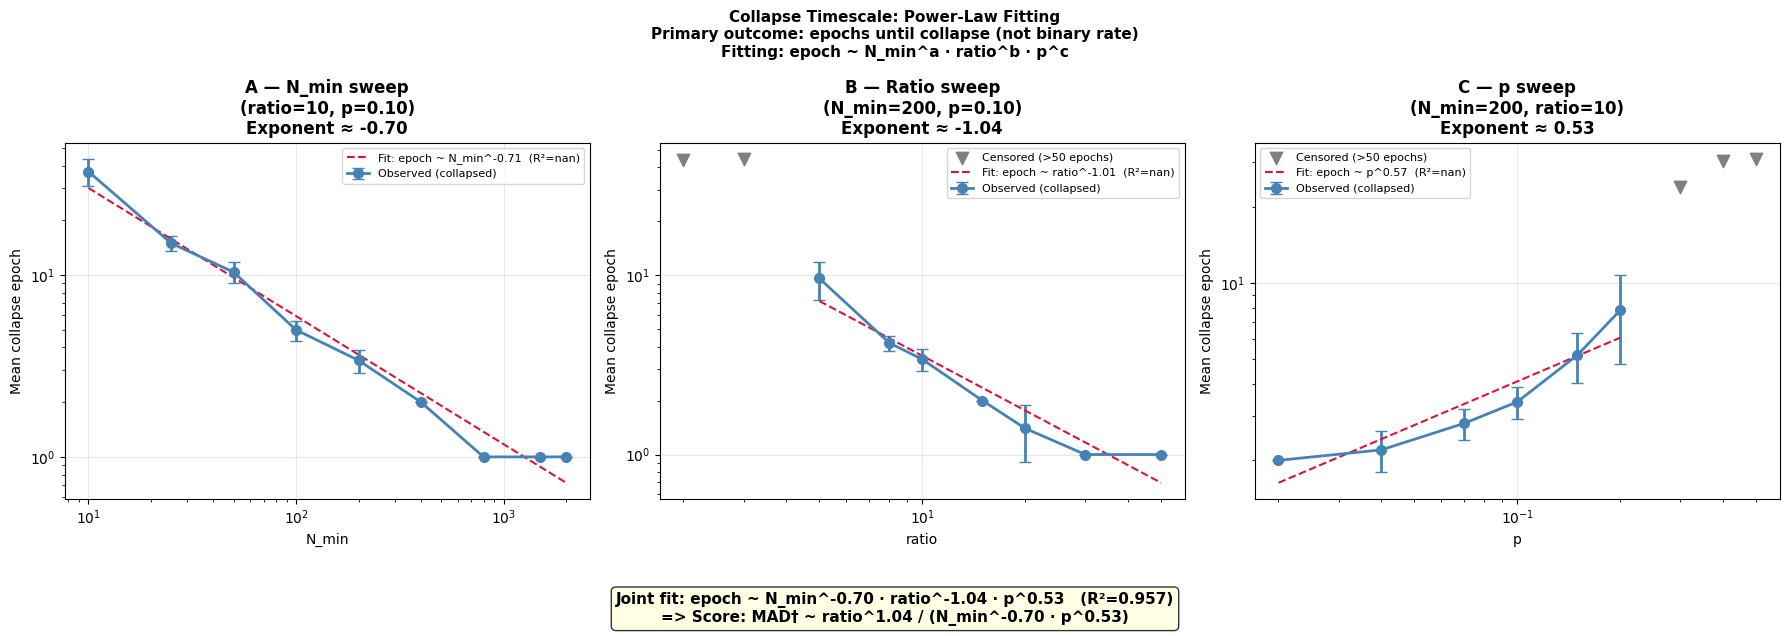

Figure saved: timescale_figure.png


In [10]:
# ── CELL 8: Figure ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    'Collapse Timescale: Power-Law Fitting\n'
    'Primary outcome: epochs until collapse (not binary rate)\n'
    'Fitting: epoch ~ N_min^a · ratio^b · p^c',
    fontweight='bold', fontsize=11)

def plot_sweep(ax, df, x_col, x_label, exponent, r2_val, panel_label):
    uncensored = df[df['censored'] == 0]
    censored   = df[df['censored'] > 0]

    ax.errorbar(uncensored[x_col], uncensored['mean_epoch'],
                yerr=uncensored['std_epoch'],
                fmt='o-', color='steelblue', linewidth=2,
                markersize=7, capsize=4, label='Observed (collapsed)')
    if len(censored) > 0:
        ax.scatter(censored[x_col], censored['mean_epoch'],
                   marker='v', color='gray', s=80, zorder=5,
                   label=f'Censored (>{N_EPOCHS} epochs)')

    # Power-law fit line
    if len(uncensored) >= 2 and not math.isnan(exponent):
        x_range = np.linspace(uncensored[x_col].min(),
                              uncensored[x_col].max(), 50)
        # Use per-sweep fit for overlay
        log_x = np.log(uncensored[x_col].values)
        log_y = np.log(uncensored['mean_epoch'].values)
        sl, ic, _, _, _ = stats.linregress(log_x, log_y)
        y_fit = np.exp(ic) * x_range ** sl
        ax.plot(x_range, y_fit, '--', color='crimson', linewidth=1.5,
                label=f'Fit: epoch ~ {x_label}^{sl:.2f}  (R²={r2_val:.2f})')

    ax.set_xlabel(x_label)
    ax.set_ylabel('Mean collapse epoch')
    ax.set_title(f'{panel_label}\nExponent ≈ {exponent:.2f}', fontweight='bold')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend(fontsize=8)
    ax.yaxis.grid(True, alpha=0.3)
    ax.xaxis.grid(True, alpha=0.3)

# Individual sweep R² values
r2_a = r2_b = r2_c = float('nan')
if 'slope_a' in dir(): r2_a = r_a**2
if 'slope_b' in dir(): r2_b = r_b**2
if 'slope_c' in dir(): r2_c = r_c**2

plot_sweep(axes[0], df_S1, 'N_min',  'N_min',  a if not math.isnan(a) else 0, r2_a, 'A — N_min sweep\n(ratio=10, p=0.10)')
plot_sweep(axes[1], df_S2, 'ratio',  'ratio',  b if not math.isnan(b) else 0, r2_b, 'B — Ratio sweep\n(N_min=200, p=0.10)')
plot_sweep(axes[2], df_S3, 'p_min',  'p',      c if not math.isnan(c) else 0, r2_c, 'C — p sweep\n(N_min=200, ratio=10)')

# Annotate joint fit result
if not math.isnan(a):
    fig.text(0.5, -0.04,
             f'Joint fit: epoch ~ N_min^{a:.2f} · ratio^{b:.2f} · p^{c:.2f}   '
             f'(R²={r2:.3f})\n'
             f'=> Score: MAD† ~ ratio^{-b:.2f} / (N_min^{a:.2f} · p^{c:.2f})',
             ha='center', fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig('timescale_figure.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: timescale_figure.png')

In [11]:
# ── CELL 9: Save all results and summary ──────────────────────
df_all_out = pd.concat([df_S1, df_S2, df_S3], ignore_index=True)
df_all_out.to_csv('timescale_results.csv', index=False)

summary = {
    'experiment': 'collapse_timescale_power_law',
    'design': {
        'sweep_1': 'N_min in [10..2000], ratio=10, p=0.10',
        'sweep_2': 'ratio in [2..50], N_min=200, p=0.10',
        'sweep_3': 'p in [0.02..0.50], N_min=200, ratio=10',
        'epochs': N_EPOCHS,
        'seeds': SEEDS,
        'censored_value': N_EPOCHS + 1,
    },
    'fitted_exponents': {
        'a_N_min':   round(float(a), 4) if not math.isnan(a) else None,
        'b_ratio':   round(float(b), 4) if not math.isnan(b) else None,
        'c_p':       round(float(c), 4) if not math.isnan(c) else None,
        'const':     round(float(const), 4) if not math.isnan(const) else None,
        'joint_R2':  round(float(r2), 4) if not math.isnan(r2) else None,
    },
    'implied_score': (
        f'MAD† ~ ratio^{-b:.2f} / (N_min^{a:.2f} · p^{c:.2f})'
        if not math.isnan(a) else 'insufficient data for joint fit'
    ),
    'key_questions_answered': [
        'Does absolute N_min matter? YES (Quick Kill confirmed)',
        'What is the N_min exponent? (see a above)',
        'What is the ratio exponent? (see b above)',
        'What is the p exponent? (see c above — discriminates 1/p vs log(1/p))',
    ],
    'interpretation_guide': {
        'a < 0': 'Drift dominates: larger N → faster collapse (confirmed by Quick Kill)',
        'a > 0': 'Noise protective: larger N → slower collapse (Ito theory)',
        'b < 0': 'Higher ratio → faster collapse (expected)',
        'c > 0': 'More minority-class signal → slower collapse (expected)',
        'c ~ 1': 'Linear in p (supports 1/p in score)',
        'c ~ 0': 'p does not matter — score needs no p term',
    }
}

with open('timescale_summary.json', 'w') as fh:
    json.dump(summary, fh, indent=2)

print('=== FINAL SUMMARY ===')
print(json.dumps(summary, indent=2))
print()
print('Files:')
for f in ['timescale_results.csv', 'timescale_figure.png', 'timescale_summary.json']:
    print(f'  {f}')
print()
print('Paste ALL output back to Claude.')
print('The exponents a, b, c determine the correct MAD† formula.')

=== FINAL SUMMARY ===
{
  "experiment": "collapse_timescale_power_law",
  "design": {
    "sweep_1": "N_min in [10..2000], ratio=10, p=0.10",
    "sweep_2": "ratio in [2..50], N_min=200, p=0.10",
    "sweep_3": "p in [0.02..0.50], N_min=200, ratio=10",
    "epochs": 50,
    "seeds": [
      42,
      0,
      1,
      7,
      99
    ],
    "censored_value": 51
  },
  "fitted_exponents": {
    "a_N_min": -0.7044,
    "b_ratio": -1.0428,
    "c_p": 0.5329,
    "const": 8.6793,
    "joint_R2": 0.9568
  },
  "implied_score": "MAD\u2020 ~ ratio^1.04 / (N_min^-0.70 \u00b7 p^0.53)",
  "key_questions_answered": [
    "Does absolute N_min matter? YES (Quick Kill confirmed)",
    "What is the N_min exponent? (see a above)",
    "What is the ratio exponent? (see b above)",
    "What is the p exponent? (see c above \u2014 discriminates 1/p vs log(1/p))"
  ],
  "interpretation_guide": {
    "a < 0": "Drift dominates: larger N \u2192 faster collapse (confirmed by Quick Kill)",
    "a > 0": "Noise p